**Explanation of columns from the kaggle dataset owner**
<ul><li>1. RowNumber—corresponds to the record (row) number and has no effect on the output. </li>
<li>2. CustomerId—contains random values and has no effect on customer leaving the bank.</li>
<li>3. Surname—the surname of a customer has no impact on their decision to leave the bank.</li>
<li>4. CreditScore—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.</li>
<li>5. Geography—a customer’s location can affect their decision to leave the bank.</li>
<li>6. Gender—it’s interesting to explore whether gender plays a role in a customer leaving the bank.</li>
<li>7. Age—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.</li>
<li>8. Tenure—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.</li>
<li>9. Balance—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.</li>
<li>10. NumOfProducts—refers to the number of products that a customer has purchased through the bank.</li>
<li>11. HasCrCard—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.</li>
<li>12. IsActiveMember—active customers are less likely to leave the bank.</li>
<li>13. EstimatedSalary—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.</li>
<li>14. Exited—whether or not the customer left the bank.</li>
<li>15. Complain—customer has complaint or not.</li>
<li>16. Satisfaction Score—Score provided by the customer for their complaint resolution.</li>
<li>17. Card Type—type of card hold by the customer.</li>
<li>18. Points Earned—the points earned by the customer for using credit card.</li>

**My assumptions:**
<li>Balance is in Euro since all 3 countries in dataset are EMU members, thus comparible not requiring normalizations 
<li>Cross-sectional data as we do not have any dates for anything

In [1]:
# Libraries

import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
# database path
db_path = os.path.join('..', 'Database', 'churn_database.db')

# connecting and reading
conn = sqlite3.connect(db_path)
query = "SELECT * FROM stg_churn_data"
df = pd.read_sql(query, conn)
conn.close()

# checking the first rows to get an understaning of how the rows and columns look
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [ ]:
# zero missing values. I intentionally chose a clean dataset. However, I do acknowledge that real world
# datasets involve lots of cleaning and handling of missing values. 
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [5]:
# balance between churned and not churned customers
df['Exited'].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

In [6]:
# correlates number columns
df.corr(numeric_only=True)['Exited'].sort_values(ascending=False)

Exited                1.000000
Complain              0.995693
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
CustomerId           -0.006203
HasCrCard            -0.006976
Tenure               -0.013656
RowNumber            -0.016140
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64

- We should probably drop "complain" since it correlates extremely highly with churn. We don't really know the nature of the column and it would probably have been more useful if it was on a more granualar level showing the nature of the complaint and when it occured.

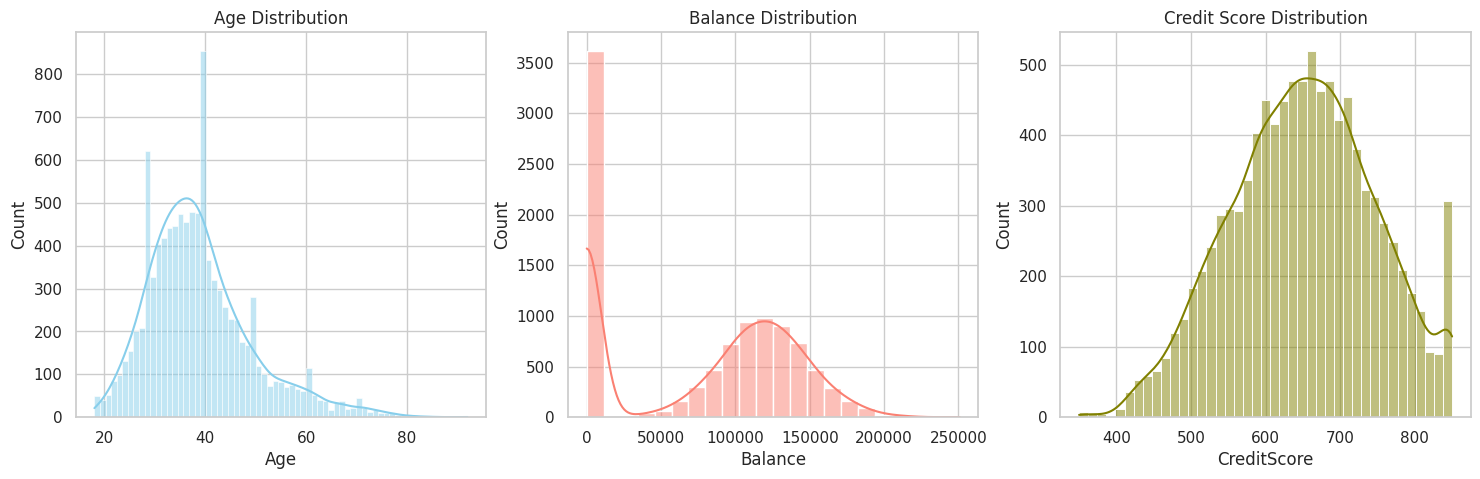

In [ ]:
# looking at distributions to understand the data we're working with
# style
sns.set_theme(style="whitegrid")

# creating a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# - age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

# - balance Distribution
sns.histplot(df['Balance'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Balance Distribution')

# - credit Score Distribution
sns.histplot(df['CreditScore'], kde=True, ax=axes[2], color='olive')
axes[2].set_title('Credit Score Distribution')

plt.show()

**Age:** The distribution is right-skewed, peaking between 35-40.

- Insight: Younger customers might have different churn drivers than retirees.

**Balance:** A bimodal distribution is observed. A large segment of customers has a near-zero balance, while the rest follow a normal distribution centered around 125,000.

- Action: I should investigate if zero-balance customers are more likely to churn (Exited=1).

**Credit Score:** Follows a normal distribution centered at ~650.

- Insight: Most customers fall into "Fair to Good" credit categories; the data appears clean with no major outliers. assuming higher score is better. small spike at the very end (850) might be because of cap.

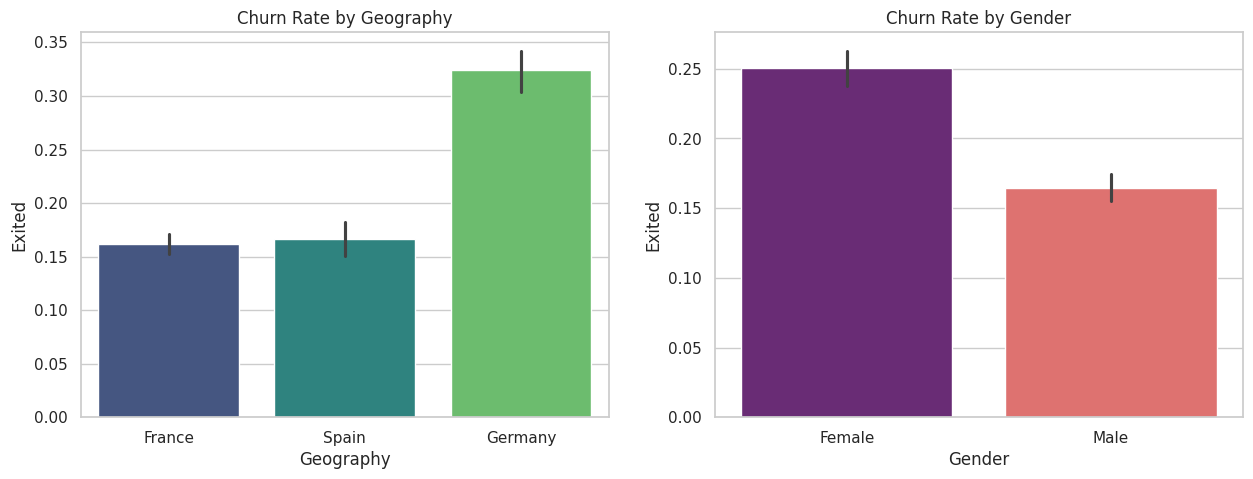

Geography
Germany    0.324432
Spain      0.166734
France     0.161747
Name: Exited, dtype: float64

In [11]:
# churn by Geography & Gender
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=df, x='Geography', y='Exited', ax=axes[0], palette='viridis')
axes[0].set_title('Churn Rate by Geography')

sns.barplot(data=df, x='Gender', y='Exited', ax=axes[1], palette='magma')
axes[1].set_title('Churn Rate by Gender')

# to keep it clean, usually good to have but makes output more readable in this case
warnings.filterwarnings("ignore")
# CHECK THIS OUT, IT DOESN'T SEEM TO WORK, WHY?

plt.show()

# churn rate by Country
df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)


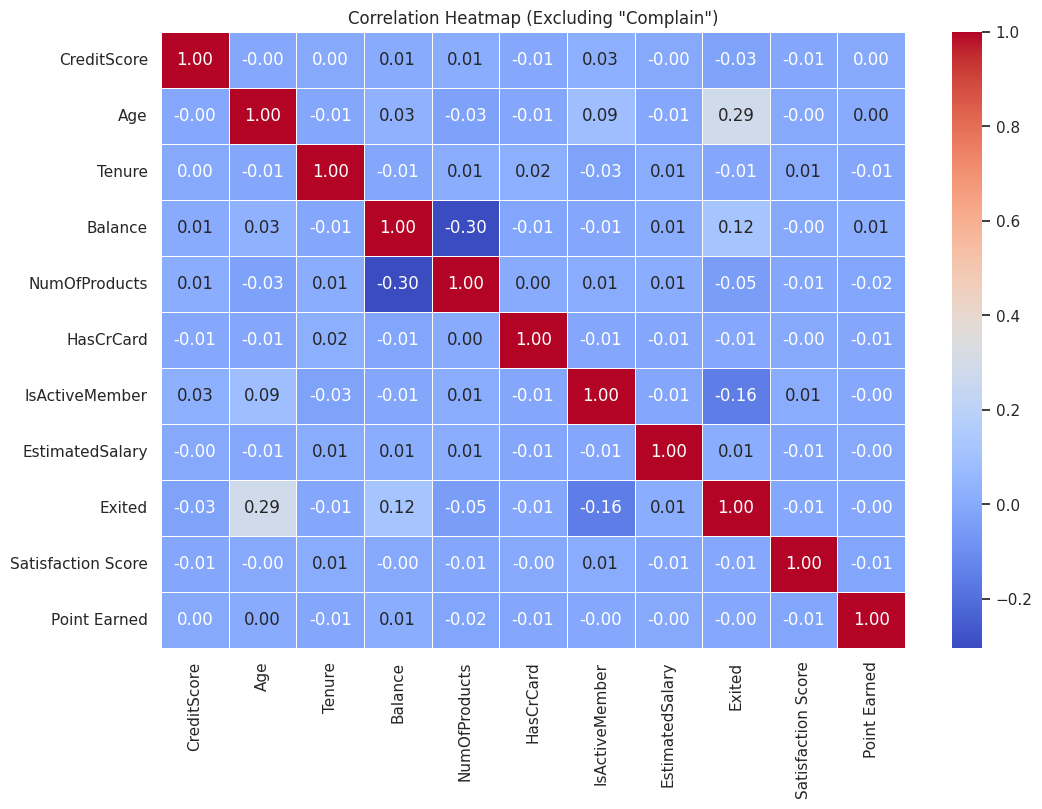

In [ ]:
# Droping the columns we know are IDs or leaky (complain is dropped since we don't know the nature of this column and it's too high of a correlation)
cols_to_exclude = ['RowNumber', 'CustomerId', 'Surname', 'Complain']
df_eda = df.drop(columns=cols_to_exclude)

# Calculate correlation
corr_matrix = df_eda.corr(numeric_only=True)

# Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Excluding "Complain")')
plt.show()

- Not many linear relatiotionships
- Age and Balance have a slight correlation.

This means churn is complex in this case, i.e. not something that can be observed easily in the data and will require more advanced machine learning models to predict.

While the numerical correlation matrix suggests Age (0.29) is the primary driver, the lack of strong linear correlation across other features suggests that churn behavior is non-linear and likely driven by categorical factors (e.g., Geography) and complex interactions that require a non-linear model like XGBoost.

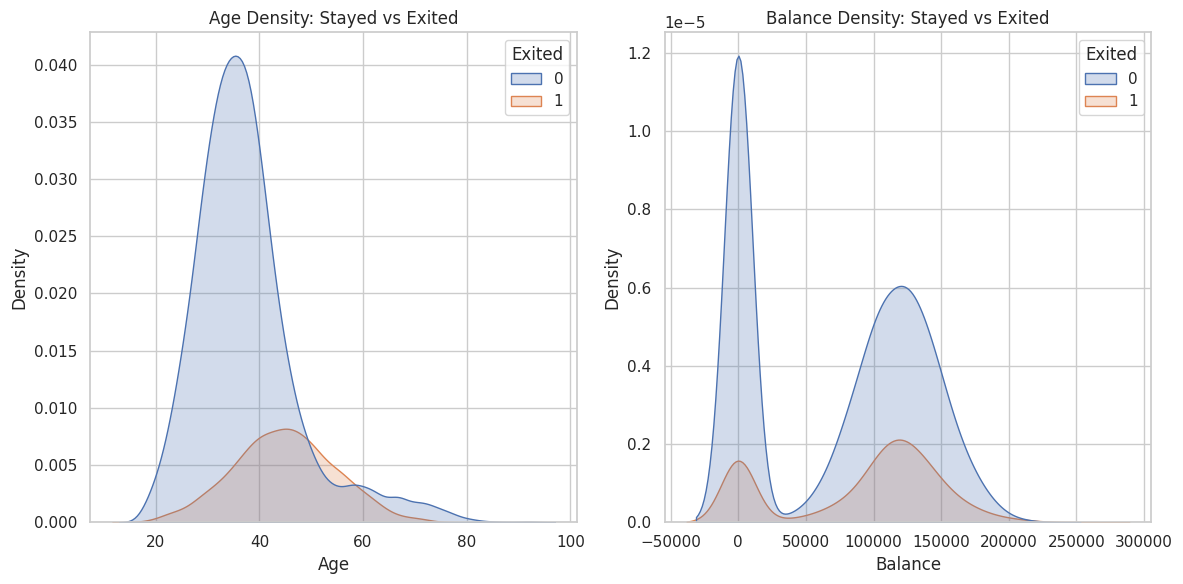

In [15]:
plt.figure(figsize=(12, 6))

# Plotting Age vs Churn
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True)
plt.title('Age Density: Stayed vs Exited')

# Plotting Balance vs Churn
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='Balance', hue='Exited', fill=True)
plt.title('Balance Density: Stayed vs Exited')

plt.tight_layout()
plt.show()

**Age:** 

- The Plot shows that loyal customers peak at age 35, but those who churn peak much later at age 45-50.

- Insight: Churn isn't random middle aged customers are much more likely to leave than younger ones.

**Balance:** (Bimodal, hence two peaks, one at zero and one between 100 000 and 150 000)

- Zero Balance: The large spike at $0 shows that "non-savers" are actually very loyal and stay with the bank.

- High Balance: In contrast, the churn group is more concentrated in the $100k+ range.

- Insight: High balance customers are a higher risk group compared to zero-balance customers.